In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import random

K-MEANS

In [44]:
n_centers = random.randint(1, 20)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=42)

print(f"Se generaron {n_centers}")

print("Coordenadas de los centroides:")
print(blob_centers)

Se generaron 18
Coordenadas de los centroides:
[[-9.47458257  4.67291684]
 [ 5.73721723 -1.00081292]
 [ 6.80422427 -5.08708095]
 [ 2.61457472 -8.14370472]
 [ 8.78914782  3.47626381]
 [ 1.38978247 -5.92944152]
 [-3.17200759  1.67408331]
 [-6.95070981 -1.12582329]
 [ 7.83576183  6.61622391]
 [-8.55471905 -8.5716417 ]
 [ 0.40045328 -0.18294336]
 [-9.78121006 -6.53862241]
 [-1.83726003 -0.74264934]
 [-3.35482238 -9.16540277]
 [-7.88817497  9.53775882]
 [ 9.66461035 -2.69946776]
 [ 2.5673971   5.4939013 ]
 [ 9.80580999 -5.17683955]]


In [45]:
import matplotlib.pyplot as plt

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

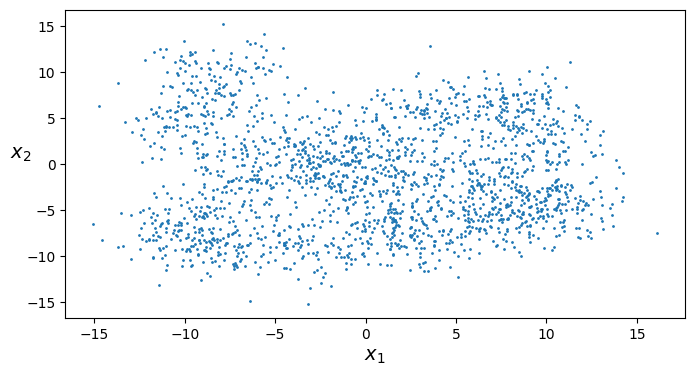

In [46]:
plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [47]:
from sklearn.cluster import KMeans

k = len(blob_centers)
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred= kmeans.fit_predict(X)
y_pred

array([ 7,  8, 10, ..., 15,  5, 11], dtype=int32)

In [48]:
kmeans.cluster_centers_

array([[ -4.13854967,   0.97803431],
       [  9.69575241,   2.55747515],
       [ -0.36904786, -10.03818269],
       [-10.17600746,  -7.95405714],
       [  4.66517834,  -1.19743691],
       [ -8.45126303,  10.60653772],
       [ 11.08600201,  -5.55788456],
       [  0.10229685,   2.54229444],
       [  9.00266657,  -2.65787887],
       [-10.21012593,   3.70053545],
       [ -7.54985405,  -2.84009711],
       [  8.31531141,   6.93947254],
       [  1.96654956,  -6.53168981],
       [ -6.92851142,   6.65411382],
       [  3.61929276,   6.13856702],
       [  6.52152118,  -6.77349296],
       [ -5.42110125,  -8.58696644],
       [ -0.76093892,  -2.19914825]])

In [49]:
X_news=np.array([[2,6],[3,2],[-3,6],[-9,2]])
kmeans.predict(X_news)

array([14,  7, 13,  9], dtype=int32)

In [50]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=10, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=10,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)

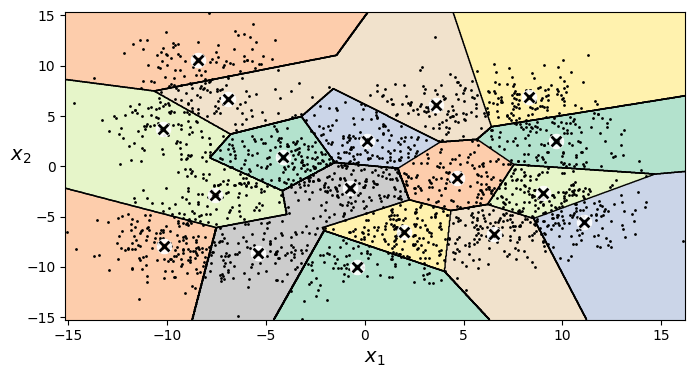

In [51]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

hacemos solf clustering

In [52]:
kmeans.transform(X_news)

array([[ 7.93107378,  8.43063357, 16.21220811, 18.51947268,  7.67504226,
        11.42143111, 14.70170493,  3.94423694, 11.13535835, 12.42476207,
        13.01334044,  6.38480751, 12.53173445,  8.95243995,  1.62521071,
        13.55013934, 16.36619485,  8.651521  ],
       [ 7.21133172,  6.71891947, 12.50073301, 16.51334085,  3.60505502,
        14.32494036, 11.06819983,  2.94801065,  7.59788401, 13.3191309 ,
        11.60715127,  7.25609567,  8.59405322, 10.96522296,  4.18464581,
         9.45385055, 13.52770508,  5.63715421],
       [ 5.1494111 , 13.1542049 , 16.25254482, 15.69110556, 10.51465915,
         7.13697824, 18.22087122,  4.64542501, 14.79942131,  7.56792265,
         9.94225773, 11.35424507, 13.47998012,  3.98259549,  6.62074297,
        15.93177605, 14.78652499,  8.49937801],
       [ 4.96770704, 18.70406203, 14.81253447, 10.02328524, 14.03426884,
         8.62401321, 21.4608736 ,  9.11843688, 18.59547899,  2.0871573 ,
         5.05266893, 18.0060656 , 13.89442119,  5.094

In [53]:
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="full", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1,
                    #  algorithm="lloyd", max_iter=1, random_state=1)
# kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=5,
                    #  algorithm="elkan", max_iter=1, random_state=1)
# Configuración del modelo K-Means con inicialización inteligente
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                      algorithm="elkan", max_iter=3, random_state=4)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=2, random_state=1)
# kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=2, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=2, random_state=1)

# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1,
#                      algorithm="full", max_iter=3, random_state=1)
# kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=5,
#                      algorithm="elkan", max_iter=3, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1,
                     algorithm="elkan", max_iter=3, random_state=5)
kmeans_iter1.fit(X)
print(kmeans_iter1)
kmeans_iter2.fit(X)
print(kmeans_iter2)
kmeans_iter3.fit(X)
print(kmeans_iter3)

KMeans(algorithm='elkan', max_iter=3, n_clusters=18, n_init=1, random_state=4)
KMeans(algorithm='elkan', max_iter=2, n_clusters=18, n_init=1, random_state=1)
KMeans(algorithm='elkan', max_iter=3, n_clusters=18, n_init=1, random_state=5)


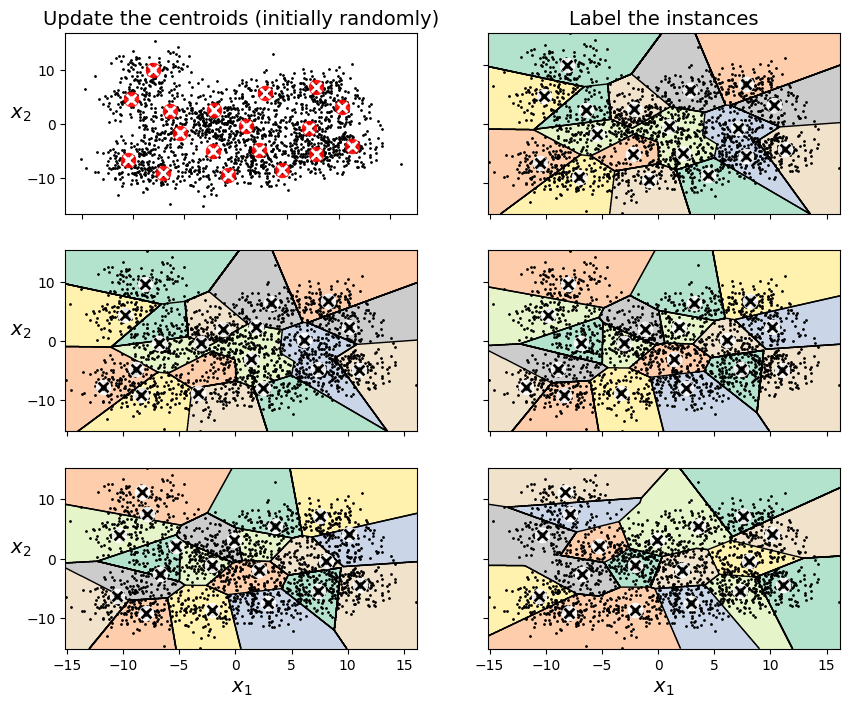

In [54]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)", fontsize=14)

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False, show_ylabels=False)
plt.title("Label the instances", fontsize=14)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False, show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

In [55]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None, title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)

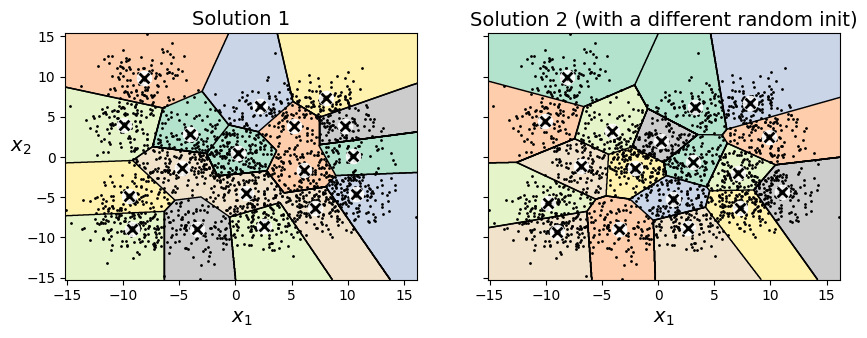

In [56]:
kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1,
                         algorithm="elkan", random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,"Solution 1", "Solution 2 (with a different random init)")

plt.show()

Para evitar que la inicialización afecte demasiado al resultado, podemos probar varias veces con diferentes valores iniciales y elegir la mejor opción, o bien utilizar la inicialización inteligente que viene por defecto en Scikit-Learn.

In [57]:
kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10,
                              algorithm="elkan", random_state=11)
kmeans_rnd_10_inits.fit(X)
print(kmeans_rnd_10_inits)

KMeans(algorithm='elkan', init='random', n_clusters=18, n_init=10,
       random_state=11)


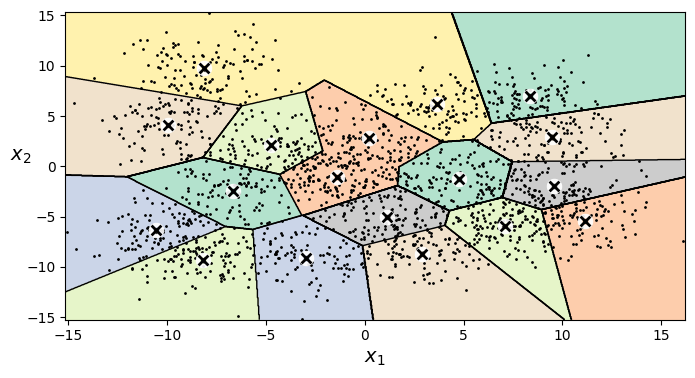

In [58]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

Mini batchs

In [59]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [60]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None

for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [61]:
best_kmeans.score(X)

-32945.10034733279

Encontrando el número óptimo de grupos

1.silhouette score

In [62]:
from sklearn.metrics import silhouette_score
silhouette_score(X, kmeans.labels_)

np.float64(0.3342385284384327)

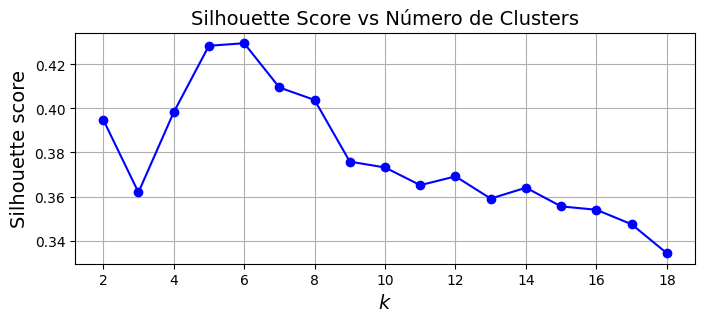

In [63]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, 10)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

2.ELBOW METHOD

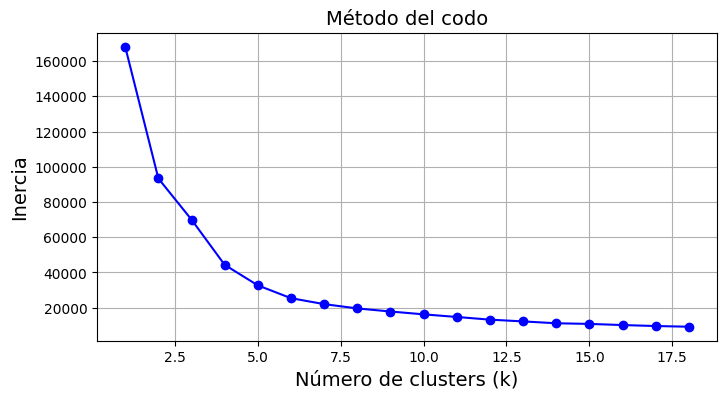

In [64]:
inertias = []
K = range(1, max_k + 1)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del codo", fontsize=14)
plt.grid(True)
plt.show()

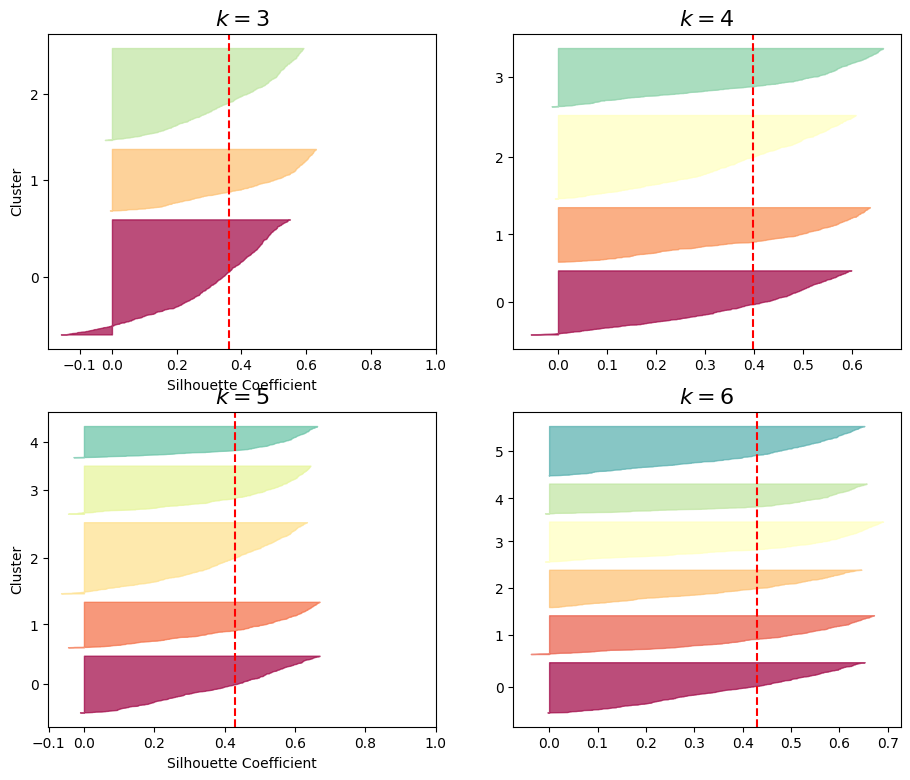

In [65]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

plt.figure(figsize=(11, 9))

valid_ks = [k for k in (3, 4, 5, 6) if k <= len(kmeans_per_k)]  # Filtrar solo los ks válidos


for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)  # enumerar para evitar errores


    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    #if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    #else:
        #plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title("$k={}$".format(k), fontsize=16)

plt.show()

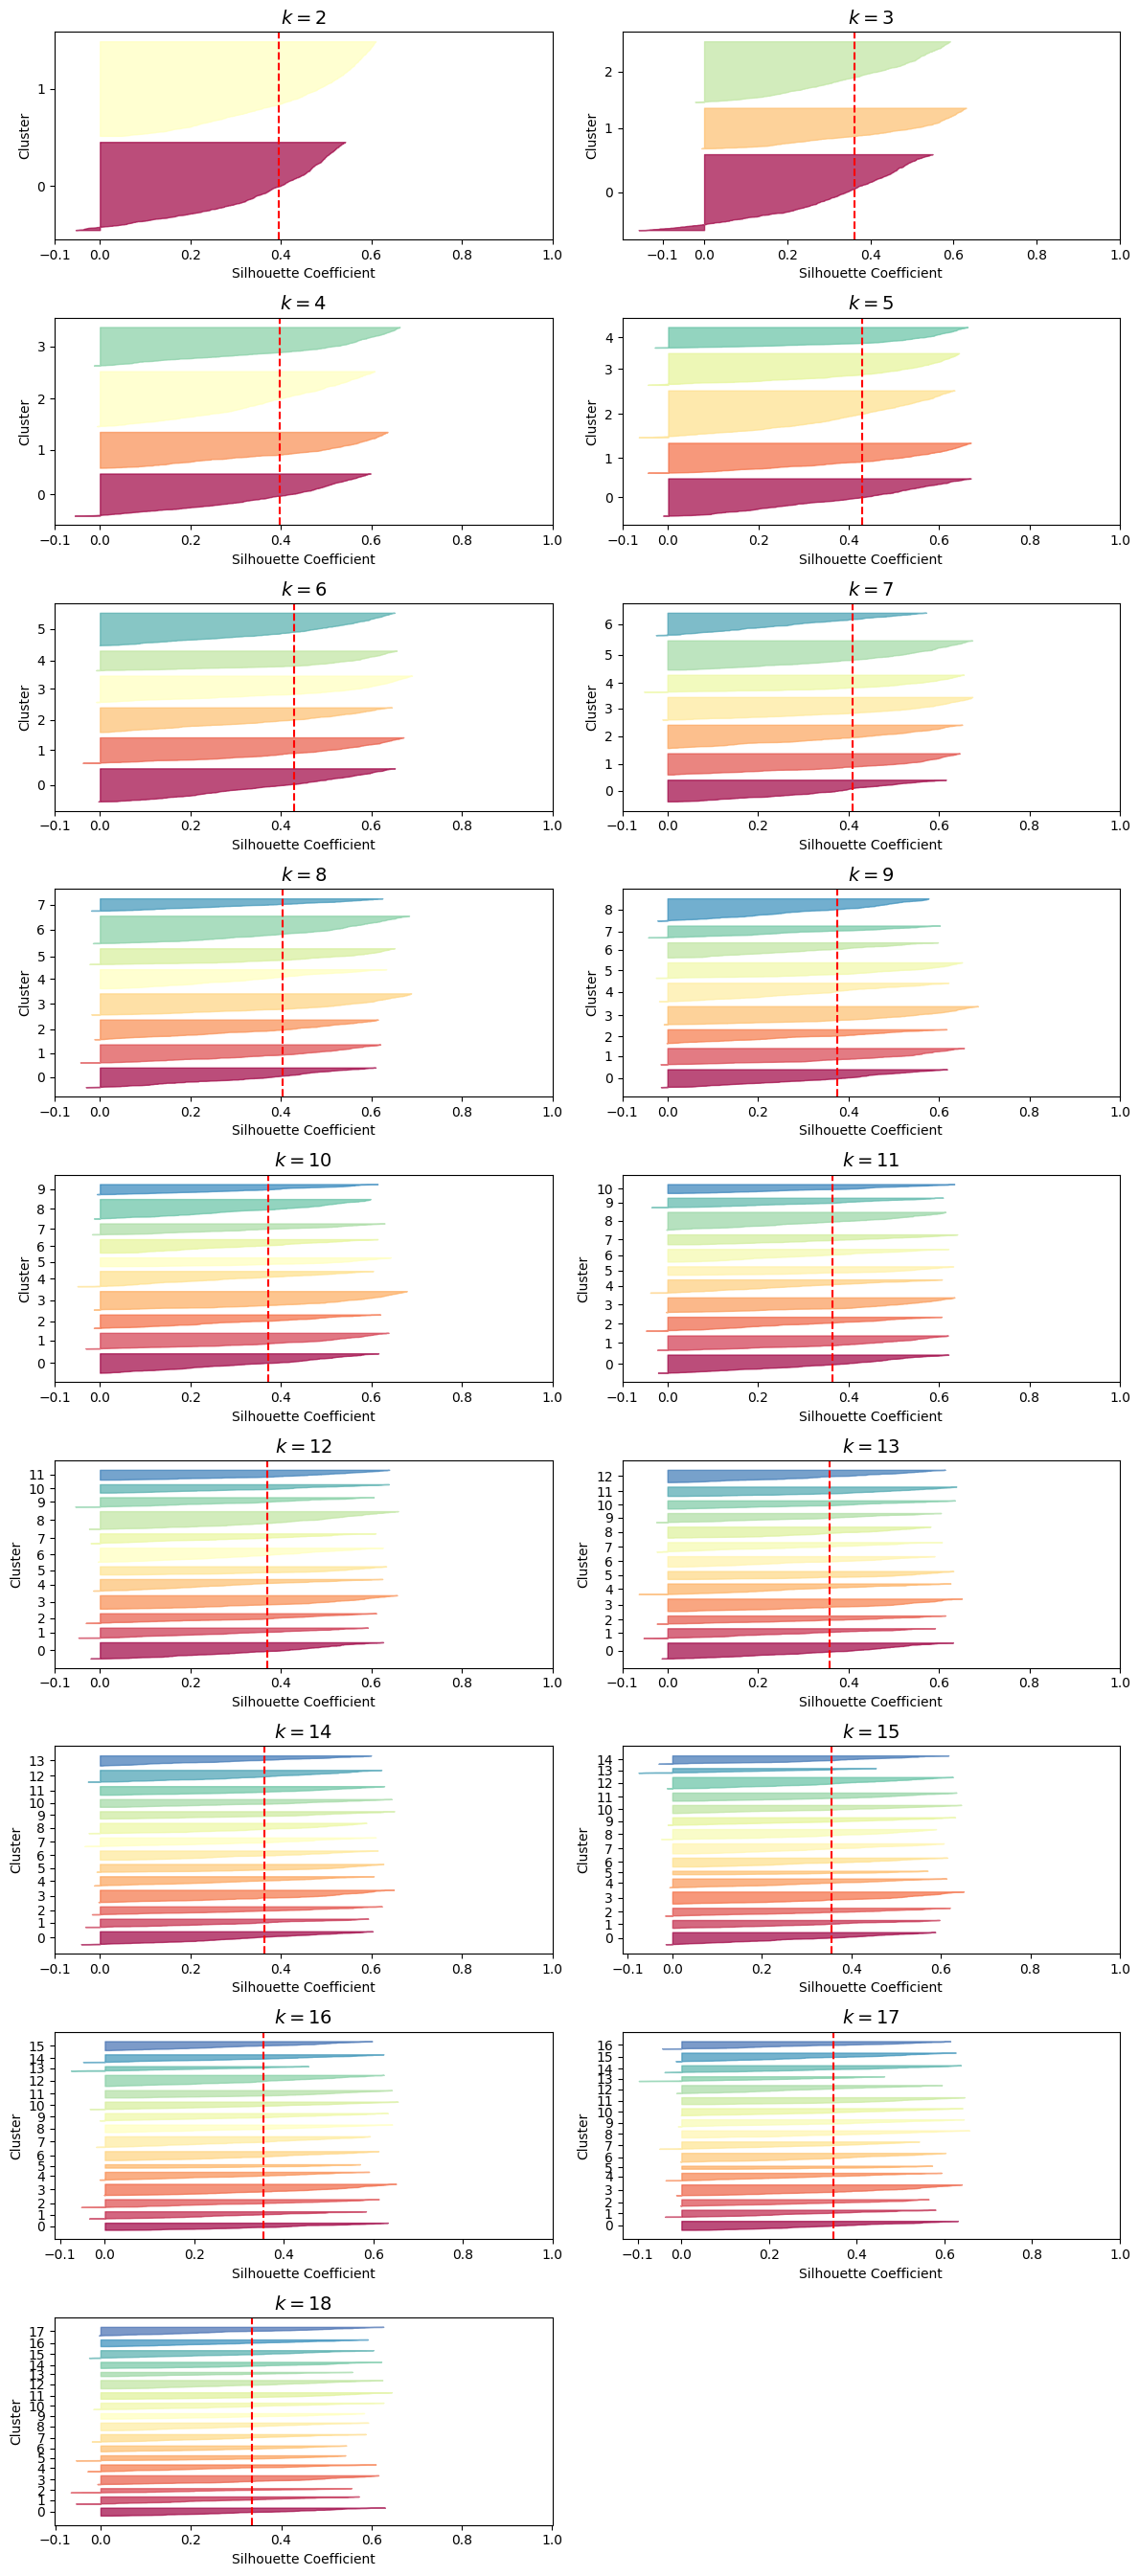

In [66]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl

n_ks = len(kmeans_per_k)  # Total de modelos entrenados
plt.figure(figsize=(12, 3 * ((n_ks - 1) // 2 + 1)))  # ajustar el alto automáticamente

for plot_idx, k in enumerate(range(2, n_ks + 1)):  # desde k=2 hasta máximo
    plt.subplot((n_ks - 1) // 2 + 1, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")

    if k - 2 < len(silhouette_scores):
        plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=14)

plt.tight_layout()
plt.show()

Aprendizaje semi-supervisado.

**Preprocesamiento**

In [39]:
imagenes_dir = '/kaggle/input/datasets/dansbecker/food-101/food-101/food-101/images/'

In [83]:
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

def cargar_con_etiquetas_ocultas(meta_train, meta_test, imagenes_dir,
                                  img_size=(32, 32), max_total=20000, seed=42):
    """
    Carga imágenes usando metadatos.
    - Las etiquetas se extraen del path (clase/imagen_id) pero se guardan OCULTAS
    - El modelo nunca ve y_all durante el clustering
    """
    rng = np.random.default_rng(seed)

    all_paths  = []
    all_labels = []

    # Construir mapeo clase → índice desde train.txt
    clases = set()
    for meta_file in [meta_train, meta_test]:
        with open(meta_file, 'r') as f:
            for line in f:
                clase = line.strip().split('/')[0]
                clases.add(clase)

    class_to_idx = {c: i for i, c in enumerate(sorted(clases))}
    print(f"Clases encontradas: {len(class_to_idx)}")

    # Leer paths + etiqueta real (oculta)
    for meta_file in [meta_train, meta_test]:
        with open(meta_file, 'r') as f:
            for line in f:
                rel_path = line.strip()
                clase    = rel_path.split('/')[0]
                full_path = f"{imagenes_dir}/{rel_path}.jpg"
                all_paths.append(full_path)
                all_labels.append(class_to_idx[clase])

    print(f"Paths totales: {len(all_paths)}")

    # Muestreo aleatorio global SIN respetar clases
    if len(all_paths) > max_total:
        idx = rng.choice(len(all_paths), size=max_total, replace=False)
        all_paths  = [all_paths[i]  for i in idx]
        all_labels = [all_labels[i] for i in idx]

    print(f"Muestra seleccionada: {len(all_paths)}")

    # Cargar imágenes
    images  = []
    labels  = []
    errores = 0

    for i, (path, label) in enumerate(zip(all_paths, all_labels)):
        try:
            with Image.open(path) as img:
                images.append(np.array(img.convert('RGB').resize(img_size), dtype=np.uint8))
                labels.append(label)
        except Exception:
            errores += 1
            continue
        if (i + 1) % 2000 == 0:
            print(f"  {i+1}/{len(all_paths)} cargadas...", flush=True)

    print(f"Cargadas OK : {len(images)}")
    print(f"Errores     : {errores}")

    return np.array(images), np.array(labels), class_to_idx


# ── Cargar ────────────────────────────────────────────────────────────────────
base_dir     = '/kaggle/input/datasets/dansbecker/food-101/food-101/food-101'
meta_train   = f'{base_dir}/meta/train.txt'
meta_test    = f'{base_dir}/meta/test.txt'
imagenes_dir = f'{base_dir}/images'

X_raw, y_all, class_to_idx = cargar_con_etiquetas_ocultas(
    meta_train, meta_test, imagenes_dir,
    img_size  = (32, 32),
    max_total = 20000
)
# ── Aplanar y normalizar ──────────────────────────────────────────────────────
X_all_flat = X_raw.reshape(len(X_raw), -1).astype(np.float32) / 255.0

Clases encontradas: 101
Paths totales: 101000
Muestra seleccionada: 20000
  2000/20000 cargadas...
  4000/20000 cargadas...
  6000/20000 cargadas...
  8000/20000 cargadas...
  10000/20000 cargadas...
  12000/20000 cargadas...
  14000/20000 cargadas...
  16000/20000 cargadas...
  18000/20000 cargadas...
  20000/20000 cargadas...
Cargadas OK : 20000
Errores     : 0


Split 

In [85]:
# 10% evaluación final
X_pool, X_eval, y_pool, y_eval = train_test_split(
    X_all_flat, y_all,
    test_size  = 0.10,
    random_state = 42,
    stratify   = y_all
)

# 5% etiquetado, 95% sin etiqueta
X_labeled, X_unlabeled, y_labeled, y_unlabeled_hidden = train_test_split(
    X_pool, y_pool,
    test_size    = 0.95,
    random_state = 42,
    stratify     = y_pool
)

# X_raw equivalente para visualización (sin aplanar)
X_raw_pool, X_raw_eval = train_test_split(
    X_raw, test_size=0.10, random_state=42, stratify=y_all
)[0], train_test_split(X_raw, test_size=0.10, random_state=42, stratify=y_all)[1]

_, X_raw_unlabeled = train_test_split(
    X_raw_pool, test_size=0.95, random_state=42, stratify=y_pool
)

print("\n--- Conjuntos SSL ---")
print(f"X_labeled          : {X_labeled.shape}   ← etiquetas visibles")
print(f"X_unlabeled        : {X_unlabeled.shape}  ← sin etiquetas para clustering")
print(f"y_unlabeled_hidden : {y_unlabeled_hidden.shape} ← ocultas, solo para evaluar")
print(f"X_eval             : {X_eval.shape}       ← evaluación final")
print(f"X_raw_unlabeled    : {X_raw_unlabeled.shape}  ← para visualizar representativas")


--- Conjuntos SSL ---
X_labeled          : (900, 3072)   ← etiquetas visibles
X_unlabeled        : (17100, 3072)  ← sin etiquetas para clustering
y_unlabeled_hidden : (17100,) ← ocultas, solo para evaluar
X_eval             : (2000, 3072)       ← evaluación final
X_raw_unlabeled    : (17100, 32, 32, 3)  ← para visualizar representativas


Imagina que tenemos un conjunto de imágenes sin ninguna etiqueta, es decir, solo contamos con los datos X y no sabemos a qué clase pertenece cada imagen, ni cuántas clases diferentes hay. En este caso, una buena estrategia sería aplicar el algoritmo K-Means y pedirle que agrupe las imágenes en, por ejemplo, 50 grupos. Así, podríamos identificar cuáles son las imágenes más representativas de cada grupo y hacernos una idea de la variedad que existe en el dataset.

**Normalizar**

In [117]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fit SOLO con labeled + unlabeled (nunca con eval)
X_pool_flat = np.vstack([X_labeled, X_unlabeled])  # todo el pool sin eval
scaler.fit(X_pool_flat)
# Transform de cada conjunto por separado
X_labeled_s   = scaler.transform(X_labeled)
X_unlabeled_s = scaler.transform(X_unlabeled)
X_eval_s      = scaler.transform(X_eval)            # mismo scaler, sin refitear
print(f"  X_labeled_s   : {X_labeled_s.shape}")
print(f"  X_unlabeled_s : {X_unlabeled_s.shape}")
print(f"  X_eval_s      : {X_eval_s.shape}")

  X_labeled_s   : (900, 3072)
  X_unlabeled_s : (17100, 3072)
  X_eval_s      : (2000, 3072)


**PCA**

In [121]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100, random_state=42, svd_solver='randomized')
# Fit con pool completo (labeled + unlabeled), transform todo
X_pool_s = np.vstack([X_labeled_s, X_unlabeled_s])
pca.fit(X_pool_s)
X_labeled_pca   = pca.transform(X_labeled_s)
X_unlabeled_pca = pca.transform(X_unlabeled_s)
X_eval_pca      = pca.transform(X_eval_s)
varianza = np.sum(pca.explained_variance_ratio_) * 100
print(f"  Varianza explicada : {varianza:.1f}%")
print(f"  X_labeled_pca      : {X_labeled_pca.shape}")
print(f"  X_unlabeled_pca    : {X_unlabeled_pca.shape}")
print(f"  X_eval_pca         : {X_eval_pca.shape}")

  Varianza explicada : 84.6%
  X_labeled_pca      : (900, 100)
  X_unlabeled_pca    : (17100, 100)
  X_eval_pca         : (2000, 100)


**Silhouette**

In [123]:
SILHOUETTE_SAMPLE = 3000
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), size=min(SILHOUETTE_SAMPLE, len(X_pca)), replace=False)
X_sample   = X_pca[sample_idx]


**Búsqueda del K óptimo**

In [124]:
# Food-101 tiene 101 clases reales → exploramos [20, 150]
# Paso de 10 para no tardar demasiado; luego refinamos alrededor del mejor
k_values          = list(range(20, 151, 10))
inertias          = []
silhouette_scores = []

print(f"\nBuscando K óptimo en {k_values}")
print(f"{'k':>6} | {'Inercia':>14} | {'Silhouette':>12}")
print("-" * 38)

for k in k_values:
    kmeans = MiniBatchKMeans(
        n_clusters  = k,
        random_state= 42,
        batch_size  = 4096,
        n_init      = 3,
        max_iter    = 300
    )
    kmeans.fit(X_pca)

    inertia = kmeans.inertia_
    labels_sample = kmeans.labels_[sample_idx]
    sil = silhouette_score(X_sample, labels_sample, metric='euclidean')

    inertias.append(inertia)
    silhouette_scores.append(sil)
    print(f"{k:>6} | {inertia:>14.1f} | {sil:>12.4f}", flush=True)


Buscando K óptimo en [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150]
     k |        Inercia |   Silhouette
--------------------------------------
    20 |     29001236.0 |       0.0388
    30 |     27994086.0 |       0.0272
    40 |     27191816.0 |       0.0237
    50 |     26701500.0 |       0.0204
    60 |     26196638.0 |       0.0163
    70 |     25785464.0 |       0.0187
    80 |     25514320.0 |       0.0133
    90 |     25272508.0 |       0.0133
   100 |     25073632.0 |       0.0104
   110 |     24829700.0 |       0.0095
   120 |     24578088.0 |       0.0083
   130 |     24492028.0 |       0.0062
   140 |     24324780.0 |       0.0045
   150 |     24225786.0 |       0.0059


**K óptimo inicial**

In [125]:
best_idx = int(np.argmax(silhouette_scores))
best_k   = k_values[best_idx]
best_sil = silhouette_scores[best_idx]
print(f"\nMejor K (paso grueso): {best_k}  —  silhouette = {best_sil:.4f}")



Mejor K (paso grueso): 20  —  silhouette = 0.0388


**Refinamiento fino alrededor del mejor K**

In [127]:
# Exploramos ±15 alrededor del mejor con paso 1
k_fine          = list(range(max(2, best_k - 15), best_k + 16))
inertias_fine   = []
sil_fine        = []

print(f"\nRefinando en rango [{k_fine[0]}, {k_fine[-1]}]...")
print(f"{'k':>6} | {'Inercia':>14} | {'Silhouette':>12}")
print("-" * 38)

for k in k_fine:
    kmeans = MiniBatchKMeans(
        n_clusters  = k,
        random_state= 42,
        batch_size  = 4096,
        n_init      = 5,
        max_iter    = 300
    )
    kmeans.fit(X_pca)

    inertia = kmeans.inertia_
    labels_sample = kmeans.labels_[sample_idx]
    sil = silhouette_score(X_sample, labels_sample, metric='euclidean')

    inertias_fine.append(inertia)
    sil_fine.append(sil)
    print(f"{k:>6} | {inertia:>14.1f} | {sil:>12.4f}", flush=True)


Refinando en rango [5, 35]...
     k |        Inercia |   Silhouette
--------------------------------------
     5 |     34147664.0 |       0.0658
     6 |     33412380.0 |       0.0542
     7 |     32625422.0 |       0.0577
     8 |     31889692.0 |       0.0569
     9 |     31431456.0 |       0.0493
    10 |     31045396.0 |       0.0516
    11 |     30813600.0 |       0.0482
    12 |     30477360.0 |       0.0467
    13 |     30237860.0 |       0.0431
    14 |     30148196.0 |       0.0402
    15 |     29871280.0 |       0.0428
    16 |     29726552.0 |       0.0416
    17 |     29396168.0 |       0.0395
    18 |     29266534.0 |       0.0349
    19 |     29102674.0 |       0.0371
    20 |     29034820.0 |       0.0336
    21 |     28884584.0 |       0.0320
    22 |     28749180.0 |       0.0336
    23 |     28645326.0 |       0.0309
    24 |     28480030.0 |       0.0343
    25 |     28374456.0 |       0.0336
    26 |     28364416.0 |       0.0314
    27 |     28292586.0 |       0

**K óptimo final**

In [128]:
best_idx_fine = int(np.argmax(sil_fine))
K_OPTIMO      = k_fine[best_idx_fine]
K_OPTIMO_SIL  = sil_fine[best_idx_fine]
print(f"\n{'='*38}")
print(f"  K ÓPTIMO FINAL : {K_OPTIMO}")
print(f"  Silhouette     : {K_OPTIMO_SIL:.4f}")
print(f"{'='*38}")


  K ÓPTIMO FINAL : 5
  Silhouette     : 0.0658


**Graficas**

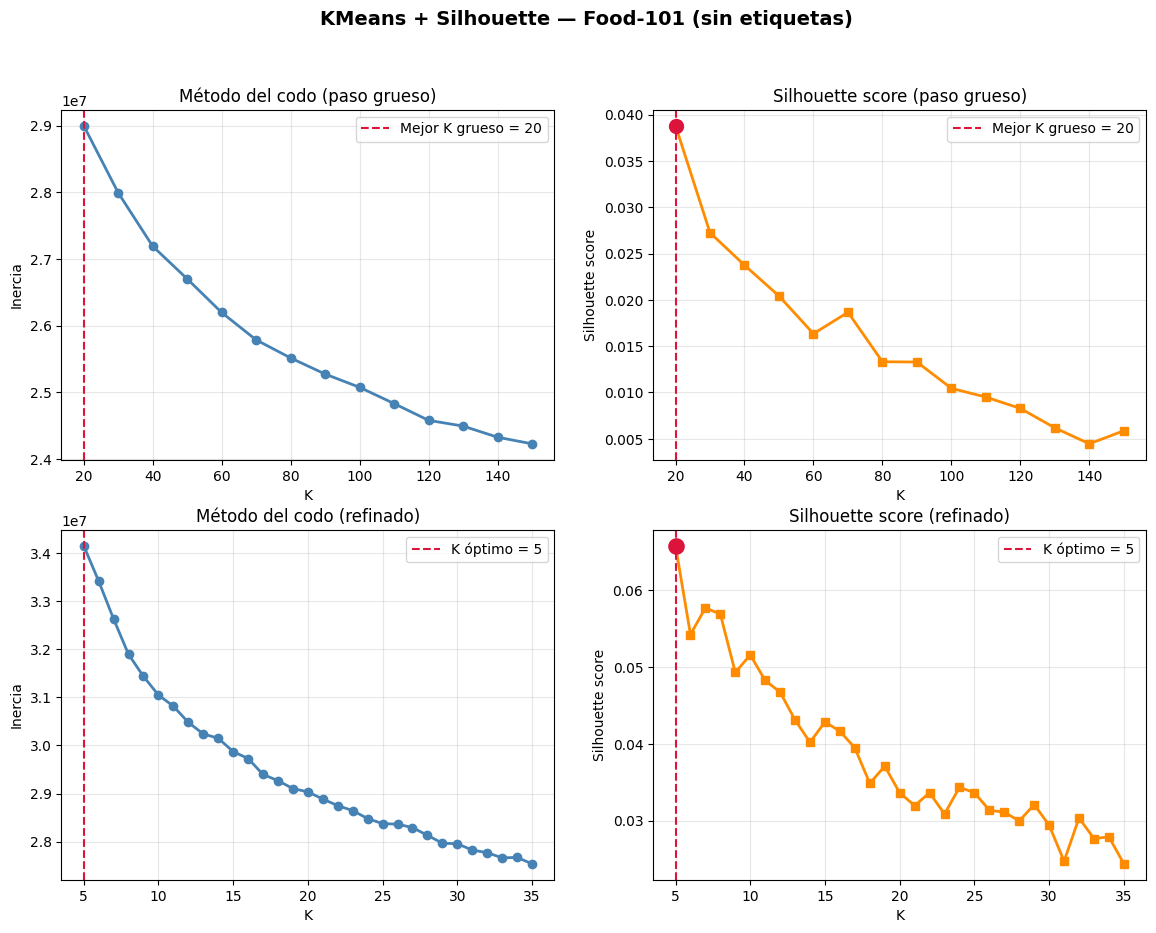

In [129]:
fig, axes = plt.subplots(2,2, figsize=(14, 10))
fig.suptitle("KMeans + Silhouette — Food-101 (sin etiquetas)", fontsize=14, fontweight='bold')
axes[0, 0].plot(k_values, inertias, 'o-', color='steelblue', linewidth=2)
axes[0, 0].axvline(x=best_k, color='crimson', linestyle='--', label=f'Mejor K grueso = {best_k}')
axes[0, 0].set_title("Método del codo (paso grueso)")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inercia")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
# 7b. Silhouette — paso grueso
axes[0, 1].plot(k_values, silhouette_scores, 's-', color='darkorange', linewidth=2)
axes[0, 1].axvline(x=best_k, color='crimson', linestyle='--', label=f'Mejor K grueso = {best_k}')
axes[0, 1].scatter([best_k], [best_sil], color='crimson', s=100, zorder=5)
axes[0, 1].set_title("Silhouette score (paso grueso)")
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("Silhouette score")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 7c. Codo — refinamiento fino
axes[1, 0].plot(k_fine, inertias_fine, 'o-', color='steelblue', linewidth=2)
axes[1, 0].axvline(x=K_OPTIMO, color='crimson', linestyle='--', label=f'K óptimo = {K_OPTIMO}')
axes[1, 0].set_title("Método del codo (refinado)")
axes[1, 0].set_xlabel("K")
axes[1, 0].set_ylabel("Inercia")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 7d. Silhouette — refinamiento fino
axes[1, 1].plot(k_fine, sil_fine, 's-', color='darkorange', linewidth=2)
axes[1, 1].axvline(x=K_OPTIMO, color='crimson', linestyle='--', label=f'K óptimo = {K_OPTIMO}')
axes[1, 1].scatter([K_OPTIMO], [K_OPTIMO_SIL], color='crimson', s=120, zorder=5)
axes[1, 1].set_title("Silhouette score (refinado)")
axes[1, 1].set_xlabel("K")
axes[1, 1].set_ylabel("Silhouette score")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

In [130]:
from sklearn.cluster import KMeans

k = K_OPTIMO
kmeans_final = MiniBatchKMeans(
    n_clusters  = K_OPTIMO,
    random_state= 42,
    batch_size  = 4096,
    n_init      = 10,
    max_iter    = 500
)
kmeans_final.fit(X_pca)

MiniBatchKMeans(batch_size=4096, max_iter=500, n_clusters=5, n_init=10,
                random_state=42)

In [131]:
X_food_dist = kmeans_final.transform(X_pca)
print(X_food_dist.shape)
print(X_food_dist)

(17100, 5)
[[67.156784 64.24643  54.37923  59.291267 61.14616 ]
 [80.72171  70.27015  65.23059  47.853016 85.51662 ]
 [41.183292 54.301903 44.139362 55.37397  50.503372]
 ...
 [72.83285  49.919098 77.15535  67.23779  62.399883]
 [52.012707 65.37124  35.010426 48.940388 63.06933 ]
 [67.62538  80.72141  57.372334 59.554626 86.47398 ]]


In [132]:
idxs = np.argmin(X_food_dist, axis=0)
X_representative = X_raw[idxs]

array([[[[167,  87,  39],
         [170,  89,  36],
         [153,  80,  27],
         ...,
         [ 21,  14,   9],
         [ 20,  15,   9],
         [ 21,  14,   8]],

        [[167,  85,  35],
         [154,  78,  31],
         [145,  75,  29],
         ...,
         [ 20,  13,   8],
         [ 22,  14,   9],
         [ 19,  14,   8]],

        [[154,  78,  28],
         [151,  75,  30],
         [152,  77,  30],
         ...,
         [ 21,  14,   8],
         [ 21,  14,   8],
         [ 20,  15,   8]],

        ...,

        [[ 39,  18,   4],
         [ 34,  16,   4],
         [ 28,  13,   3],
         ...,
         [152,  97,  26],
         [154,  99,  31],
         [157,  99,  31]],

        [[ 35,  17,   4],
         [ 35,  17,   4],
         [ 29,  15,   3],
         ...,
         [155,  95,  26],
         [156,  97,  28],
         [155,  95,  27]],

        [[ 38,  20,   4],
         [ 38,  18,   4],
         [ 36,  16,   3],
         ...,
         [157,  94,  22],
        

In [133]:
print(X_representative_digits.shape)
print(X_representative_digits)

(5, 100)
[[-1.09520137e+00  2.76656914e+00 -3.46253276e+00  1.68984241e+01
   2.88216949e+00  9.11356747e-01  4.69106627e+00 -3.18828911e-01
  -2.21263695e+00 -1.30888987e+00 -3.10634708e+00  1.81969857e+00
  -2.88899112e+00 -4.54859018e+00  9.21269476e-01  1.80179372e-01
  -1.09352994e+00 -2.03958845e+00  1.53935984e-01  7.21126437e-01
  -3.19149518e+00 -1.03304446e-01 -1.69906840e-01 -2.15639830e+00
   1.56760406e+00  3.67930794e+00 -5.58120370e-01  5.08956790e-01
   1.14484072e+00  1.60065353e+00  2.96213484e+00 -2.03515220e+00
   8.56809020e-01  9.96088922e-01 -1.28570557e+00 -3.14112492e-02
   9.63888884e-01 -2.40325749e-01  5.38914859e-01 -7.87279725e-01
  -7.07090378e-01  1.63149446e-01 -4.41926897e-01  2.19795322e+00
   5.44656992e-01 -4.33282995e+00 -1.63692474e+00  3.50049138e-01
  -5.51761150e-01  6.30638719e-01  9.93517160e-01 -2.14004099e-01
   7.91274309e-01 -1.16054094e+00  1.49019814e+00 -2.95348614e-01
  -3.41377884e-01  1.77327836e+00 -4.77130473e-01 -1.48308253e+00
 

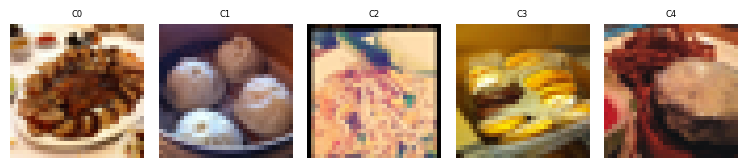

In [135]:
import matplotlib.pyplot as plt

cols = 10
filas = int(np.ceil(K_OPTIMO / cols))

plt.figure(figsize=(15, filas * 1.8))
for index, img in enumerate(X_representative):
    plt.subplot(filas, cols, index + 1)
    plt.imshow(img)          # img ya es (32, 32, 3) — no necesita reshape
    plt.title(f"C{index}", fontsize=6)
    plt.axis('off')

plt.tight_layout()
plt.savefig("representativas_por_cluster.png", dpi=150, bbox_inches='tight')
plt.show()

El siguiente paso consiste en anotar manualmente estas etiquetas (aquí haremos trampas ya que disponemos de dichas etiquetas

In [137]:
y_representative = y_all[idxs]

In [139]:
from sklearn.linear_model import LogisticRegression

log_reg_base = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)

# ✅ X_labeled_pca, no X_pca
log_reg_base.fit(X_labeled_pca, y_labeled)
print("Accuracy (solo etiquetados):", log_reg_base.score(X_eval_pca, y_eval))

Accuracy (solo etiquetados): 0.0205


Y entrenaremos un clasificados usando estas imágenes representativas.

In [142]:
X_train = np.vstack([X_labeled_pca, X_unlabeled_pca])  # (17100, 100)

# Label Spreading necesita -1 para los no etiquetados
y_train_ls = np.concatenate([
    y_labeled,                                    # etiquetas reales
    np.full(len(X_unlabeled_pca), -1, dtype=int)  # -1 = sin etiqueta
])

In [149]:
from sklearn.semi_supervised import LabelPropagation

print("Propagando etiquetas...")
lp = LabelPropagation(kernel='knn', n_neighbors=15, max_iter=1000, n_jobs=-1)
lp.fit(X_train, y_train_ls)

y_train_propagated = lp.transduction_.copy()
y_train_propagated[:len(y_labeled)] = y_labeled  # forzar etiquetas reales

Propagando etiquetas...


In [150]:
X_test, y_test = X_eval_pca, y_eval  # renombrar para consistencia con tu código

log_reg_ssl = LogisticRegression(max_iter=5000, solver='lbfgs', random_state=42)
log_reg_ssl.fit(X_train, y_train_propagated)
acc_ssl = log_reg_ssl.score(X_test, y_test)
print(f"Accuracy SSL (etiquetas propagadas): {acc_ssl:.4f}")

Accuracy SSL (etiquetas propagadas): 0.0135


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

print("Asignando etiquetas por KNN...")
knn = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)
knn.fit(X_labeled_pca, y_labeled)

# Predecir etiquetas para unlabeled
y_unlabeled_pred = knn.predict(X_unlabeled_pca)

# Combinar: labeled reales + unlabeled predichos
X_train = np.vstack([X_labeled_pca, X_unlabeled_pca])
y_train_propagated = np.concatenate([y_labeled, y_unlabeled_pred])

# Entrenar
log_reg_ssl = LogisticRegression(max_iter=5000, solver='lbfgs', n_jobs=-1, random_state=42)
log_reg_ssl.fit(X_train, y_train_propagated)
acc_ssl = log_reg_ssl.score(X_eval_pca, y_eval)
print(f"Accuracy SSL (KNN propagation): {acc_ssl:.4f}")

Asignando etiquetas por KNN...


Como puedes observar hemos obtenido una precisión de casi el 
 habiendo anotado simplemente 50 imágenes, pero aquellas más representativas. Entrenar el mismo modelo con 50 imágenes aleatorias nos daría peores resultados.

**Aprendizaje Activo**

El aprendizaje activo (o Active Learning) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [ ]:
def entropia(probas):
    """Incertidumbre por entropía: selecciona donde el modelo está más confundido"""
    probas = np.clip(probas, 1e-10, 1.0)
    return -np.sum(probas * np.log(probas), axis=1)

def margen(probas):
    """Incertidumbre por margen: selecciona donde las dos clases más probables son similares"""
    sorted_probs = np.sort(probas, axis=1)
    return sorted_probs[:, -1] - sorted_probs[:, -2]

In [ ]:
def active_learning_loop(X_labeled, y_labeled, X_unlabeled, y_unlabeled_hidden,
                         X_test, y_test, query_strategy='entropia',
                         n_queries=10, batch_size=100, random_state=42):
    rng = np.random.default_rng(random_state)

    # Copias para no modificar los originales
    X_train = X_labeled.copy()
    y_train = y_labeled.copy()
    X_pool  = X_unlabeled.copy()
    y_pool  = y_unlabeled_hidden.copy()

    acc_history = []
    
    for i in range(n_queries + 1):
        # Entrenar
        clf = LogisticRegression(max_iter=2000, solver='lbfgs', random_state=random_state)
        clf.fit(X_train, y_train)
        acc_history.append(clf.score(X_test, y_test))
        
        if i < n_queries:
            # Seleccionar muestras
            if query_strategy == 'entropia':
                probas = clf.predict_proba(X_pool)
                scores = entropia(probas)
                query_idx = np.argsort(scores)[-batch_size:]
            elif query_strategy == 'margen':
                probas = clf.predict_proba(X_pool)
                sorted_probs = np.sort(probas, axis=1)
                margin = sorted_probs[:, -1] - sorted_probs[:, -2]
                query_idx = np.argsort(margin)[:batch_size]
            else:  # aleatorio
                query_idx = rng.choice(len(X_pool), size=batch_size, replace=False)

            # Mover a etiquetados
            X_train = np.vstack([X_train, X_pool[query_idx]])
            y_train = np.concatenate([y_train, y_pool[query_idx]])

            # Eliminar del pool
            mask = np.ones(len(X_pool), dtype=bool)
            mask[query_idx] = False
            X_pool = X_pool[mask]
            y_pool = y_pool[mask]

    return acc_history

Grafica

In [ ]:
N_QUERIES   = 8
BATCH_SIZE  = 100
RANDOM_STATE= 42

print("🟢 Entrenando con Muestreo por Incertidumbre (Entropía)...")
acc_entropy = active_learning_loop(
    X_labeled_pca, y_labeled, X_unlabeled_pca, y_unlabeled_hidden,
    X_eval_pca, y_eval, query_strategy='entropia',
    n_queries=N_QUERIES, batch_size=BATCH_SIZE, random_state=RANDOM_STATE
)

print("🔵 Entrenando con Muestreo Aleatorio (baseline)...")
acc_random = active_learning_loop(
    X_labeled_pca, y_labeled, X_unlabeled_pca, y_unlabeled_hidden,
    X_eval_pca, y_eval, query_strategy='aleatorio',
    n_queries=N_QUERIES, batch_size=BATCH_SIZE, random_state=RANDOM_STATE
)

In [ ]:
plt.figure(figsize=(8, 5))
x_vals = [i * BATCH_SIZE + len(y_labeled) for i in range(N_QUERIES + 1)]

plt.plot(x_vals, acc_entropy, 'o-', label='Aprendizaje Activo (Entropía)', linewidth=2, markersize=8)
plt.plot(x_vals, acc_random, 's--', label='Muestreo Aleatorio (Baseline)', linewidth=2, markersize=8)

plt.xlabel('Número de muestras etiquetadas')
plt.ylabel('Accuracy en Test')
plt.title('Aprendizaje Activo vs Aleatorio (Food-101)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()